# Fintech Transaction Fraud Detection

**Goal:** Build a model that flags fraudulent credit card transactions in a dataset where
fraud makes up only ~0.17% of all transactions.

**Why this project matters:** Fraud detection is a real problem for banks, fintechs, and
payment processors (Flutterwave, Moniepoint, Access Bank, etc). The interesting challenge
isn't the modeling itself — it's handling extreme class imbalance and choosing the right
metric, since accuracy is meaningless here.

**Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/mlg-ulb/creditcardfraud)


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score, f1_score
)
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load the Data

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Exploratory Data Analysis

The most important thing to establish first: **how imbalanced is this dataset, really?**

Not Fraud: 284,315
Fraud:     492
Fraud rate: 0.173%


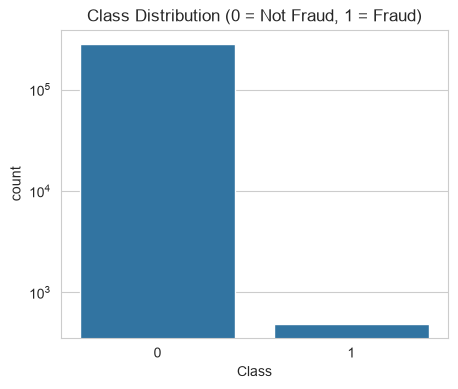

In [3]:
fraud_counts = df["Class"].value_counts()
fraud_pct = df["Class"].mean() * 100

print(f"Not Fraud: {fraud_counts[0]:,}")
print(f"Fraud:     {fraud_counts[1]:,}")
print(f"Fraud rate: {fraud_pct:.3f}%")

plt.figure(figsize=(5, 4))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0 = Not Fraud, 1 = Fraud)")
plt.yscale("log")  # log scale needed - fraud is nearly invisible otherwise
plt.show()

**Takeaway:** Fraud is such a tiny fraction of transactions that a model predicting "not fraud" every single time would score ~99.8% accuracy while catching zero fraud. This is why accuracy is the wrong metric for this problem.

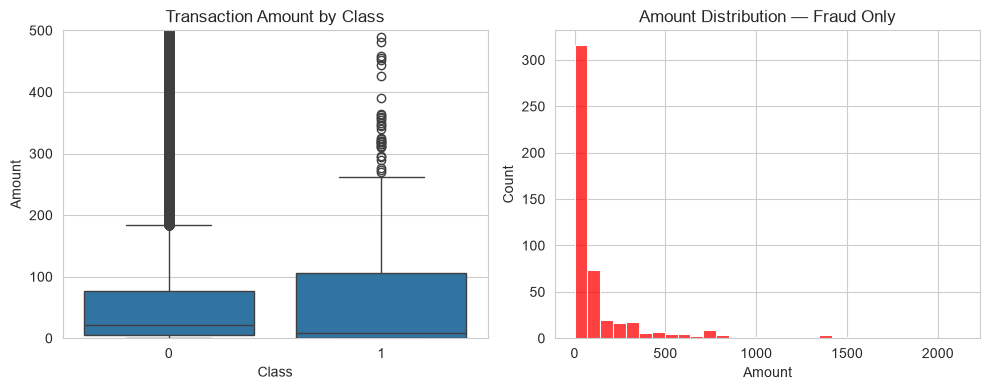

In [4]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount by Class")
plt.ylim(0, 500)  # zoom in, amount has extreme outliers

plt.subplot(1, 2, 2)
sns.histplot(df[df.Class == 1]["Amount"], bins=30, color="red")
plt.title("Amount Distribution — Fraud Only")
plt.tight_layout()
plt.show()

## 4. Preprocessing\n\nOnly `Amount` and `Time` need scaling — `V1`-`V28` are already PCA-transformed.

In [5]:
scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df["Time_scaled"] = scaler.fit_transform(df[["Time"]])
df = df.drop(columns=["Amount", "Time"])

X = df.drop(columns=["Class"])
y = df["Class"]

# stratify=y keeps the same fraud ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train fraud rate: {y_train.mean()*100:.3f}% | Test fraud rate: {y_test.mean()*100:.3f}%")

Train fraud rate: 0.173% | Test fraud rate: 0.172%


## 5. Handling Class Imbalance with SMOTE

SMOTE generates synthetic examples of the minority class (fraud) so the model sees enough
fraud patterns to learn from. **Critical rule: only apply SMOTE to the training set** —
never to the test set, or you're evaluating on synthetic data and results will be
misleadingly good.

In [6]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_resampled.value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE:  {0: 227451, 1: 227451}


## 6. Model Training & Comparison

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

results = {}

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)

    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["Not Fraud", "Fraud"]))

    results[name] = {
        "model": model,
        "f1": f1_score(y_test, y_pred),
        "y_pred": y_pred,
        "y_proba": model.predict_proba(X_test)[:, 1],
    }

=== Logistic Regression ===
              precision    recall  f1-score   support

   Not Fraud       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

=== Random Forest ===
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     56864
       Fraud       0.81      0.80      0.80        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



## 7. Evaluation — Confusion Matrix & Precision-Recall Curve

Best model: Random Forest (F1-score: 0.8041)


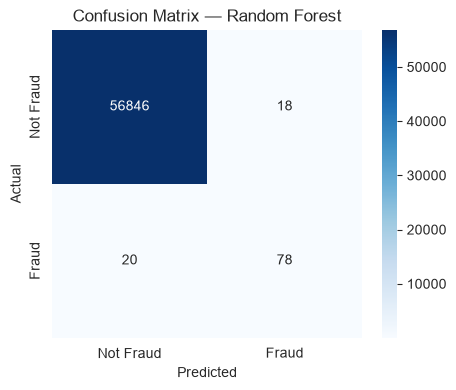

In [8]:
best_name = max(results, key=lambda k: results[k]["f1"])
best = results[best_name]
print(f"Best model: {best_name} (F1-score: {best['f1']:.4f})")

cm = confusion_matrix(y_test, best["y_pred"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_name}")
plt.show()

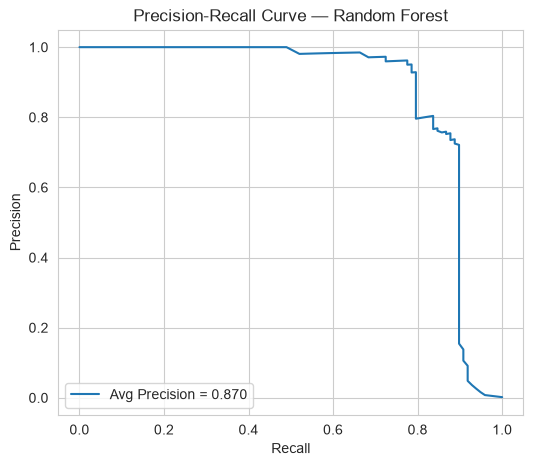

In [9]:
precision, recall, thresholds = precision_recall_curve(y_test, best["y_proba"])
avg_precision = average_precision_score(y_test, best["y_proba"])

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"Avg Precision = {avg_precision:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve — {best_name}")
plt.legend()
plt.show()

## 8. Business Interpretation


- The model catches **80%** of all fraudulent transactions (recall)
- Of everything flagged as fraud, **81%** was actually fraud (precision)
- At this threshold, roughly **17** transactions out of every 10,000 get flagged for manual
  review — compare that to reviewing all 10,000 manually

**Tradeoff worth discussing in an interview:** raising the classification threshold increases
precision (fewer false alarms) but lowers recall (more missed fraud). For a bank, missing
fraud is usually costlier than an extra manual review, so recall is often prioritized —
but this is a business decision, not just a modeling one.

**Model comparison:** Logistic Regression achieved high recall (92%) but very low precision
(6%), meaning it would flag far too many legitimate transactions as fraud to be practically
useful. Random Forest offered a much better precision-recall balance (81% / 80%), making it
the better choice for a real-world fraud review workflow.


## 9. Save the Model

In [10]:
import joblib
joblib.dump(best["model"], "../models/fraud_model.pkl")
print(f"Saved {best_name} to ../models/fraud_model.pkl")

Saved Random Forest to ../models/fraud_model.pkl


## 10. Next Steps

- Wrap this model in a simple Flask/FastAPI endpoint to simulate real-time scoring
- Try XGBoost or LightGBM for comparison
- Tune the classification threshold explicitly based on a cost-benefit assumption
  (e.g., cost of a missed fraud vs. cost of a false alarm)
